In [1]:

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
# parameters
mu_values = np.arange(0.05, 1.0001, 0.005)      # Mean Number of Photons/Pulse
alpha = 0.2                                   # Attenuation in fiber in dB/Km
delta_f = 1e3                                 # Linewidth in Hz
d_t = 1e-9                                    # 1/Bit rate
R_b = 1e9                                     # Bit rate
L = np.arange(0, 250.5, 0.5)                  # Length of Fiber
t_B = 0.5                                     # Transmittance of BS
loss_MZI = 1 * 10**(-0.2)                     # 2 dB loss in MZI
theta = 0                                     # Phase difference of two consecutive pulses
eta = 0.2                                     # Efficiency of SPD
Pd_values = np.arange(2e-7, 8.0001e-7, 0.1e-7) # Dark Count Probability
t_d = 10e-9                                   # Dead Time in SPD
t_BSE = 0.8                                   # Transmittance of Eve's BS
f_decoy = 0.2                                 # Probability used to generate the decoy state
duty_cycle_TTL = 0.75                         # Duty cycle of TTL pulses
f = 1.16                                      # Error correction efficiency

X = []
Y = []
Z = []
Color = []

for P_d in Pd_values:

    for mu in mu_values:

        # Phase Noise at LASER
        sigma = np.sqrt(2 * np.pi * delta_f * d_t)

        # Channel transmittance
        eta_channel = 10 ** (-alpha * L / 10)

        Photon_count_after_channel = mu * 10 ** (-alpha * L / 10) * R_b
        
        # DATA LINE

        Photon_count_after_BS = mu * 10 ** (-alpha * L / 10) * R_b * t_B

        Photon_count_after_D_d = Photon_count_after_BS * eta + P_d * R_b

        effective_time_difference_D_d = 1 / Photon_count_after_D_d + t_d

        effective_counts_D_d = (1 / effective_time_difference_D_d) * duty_cycle_TTL

        # MONITORING LINE

        Photon_count_after_BS = mu * 10 ** (-alpha * L / 10) * R_b * (1 - t_B)

        Photon_Count_MZI_Upper = (loss_MZI * mu * 10 ** (-alpha * L / 10) * R_b * (1 - t_B)* ((1 + np.exp(-(sigma ** 2) / 2) * np.cos(theta)) / 2))

        Photon_Count_MZI_Lower = (loss_MZI * mu * 10 ** (-alpha * L / 10) * R_b * (1 - t_B) * ((1 - np.exp(-(sigma ** 2) / 2) * np.cos(theta)) / 2))

        Photon_Count_before_SPD_0 = Photon_Count_MZI_Upper
        Photon_Count_before_SPD_1 = Photon_Count_MZI_Lower

        Photon_Count_after_SPD_0 = Photon_Count_before_SPD_0 * eta + P_d * R_b
        Photon_Count_after_SPD_1 = Photon_Count_before_SPD_1 * eta + P_d * R_b

        effective_time_difference_SPD_0 = 1 / Photon_Count_after_SPD_0 + t_d
        effective_time_difference_SPD_1 = 1 / Photon_Count_after_SPD_1 + t_d

        effective_counts_SPD_0 = ((1 / effective_time_difference_SPD_0) * duty_cycle_TTL)
        effective_counts_SPD_1 = ( (1 / effective_time_difference_SPD_1) * duty_cycle_TTL )

        total_counts_D_M1 = ((1 / effective_time_difference_SPD_0) * duty_cycle_TTL * (2 * f_decoy + (1 - f_decoy) ** 2 / 2))
        total_counts_D_M2 = ((1 / effective_time_difference_SPD_1) * duty_cycle_TTL * (2 * f_decoy + (1 - f_decoy) ** 2 / 2))

        # Visibility
        V = (total_counts_D_M1 - total_counts_D_M2) / (total_counts_D_M1 + total_counts_D_M2)
        
        # QBER
        Q_0 = (1 - V) / 2
        Q = (1 - V) * 100 / 2

        # Store data
        X.extend(L)
        Y.extend(np.ones_like(L) * mu)
        Z.extend(np.ones_like(L) * P_d * 1e7)
        Color.extend(Q)



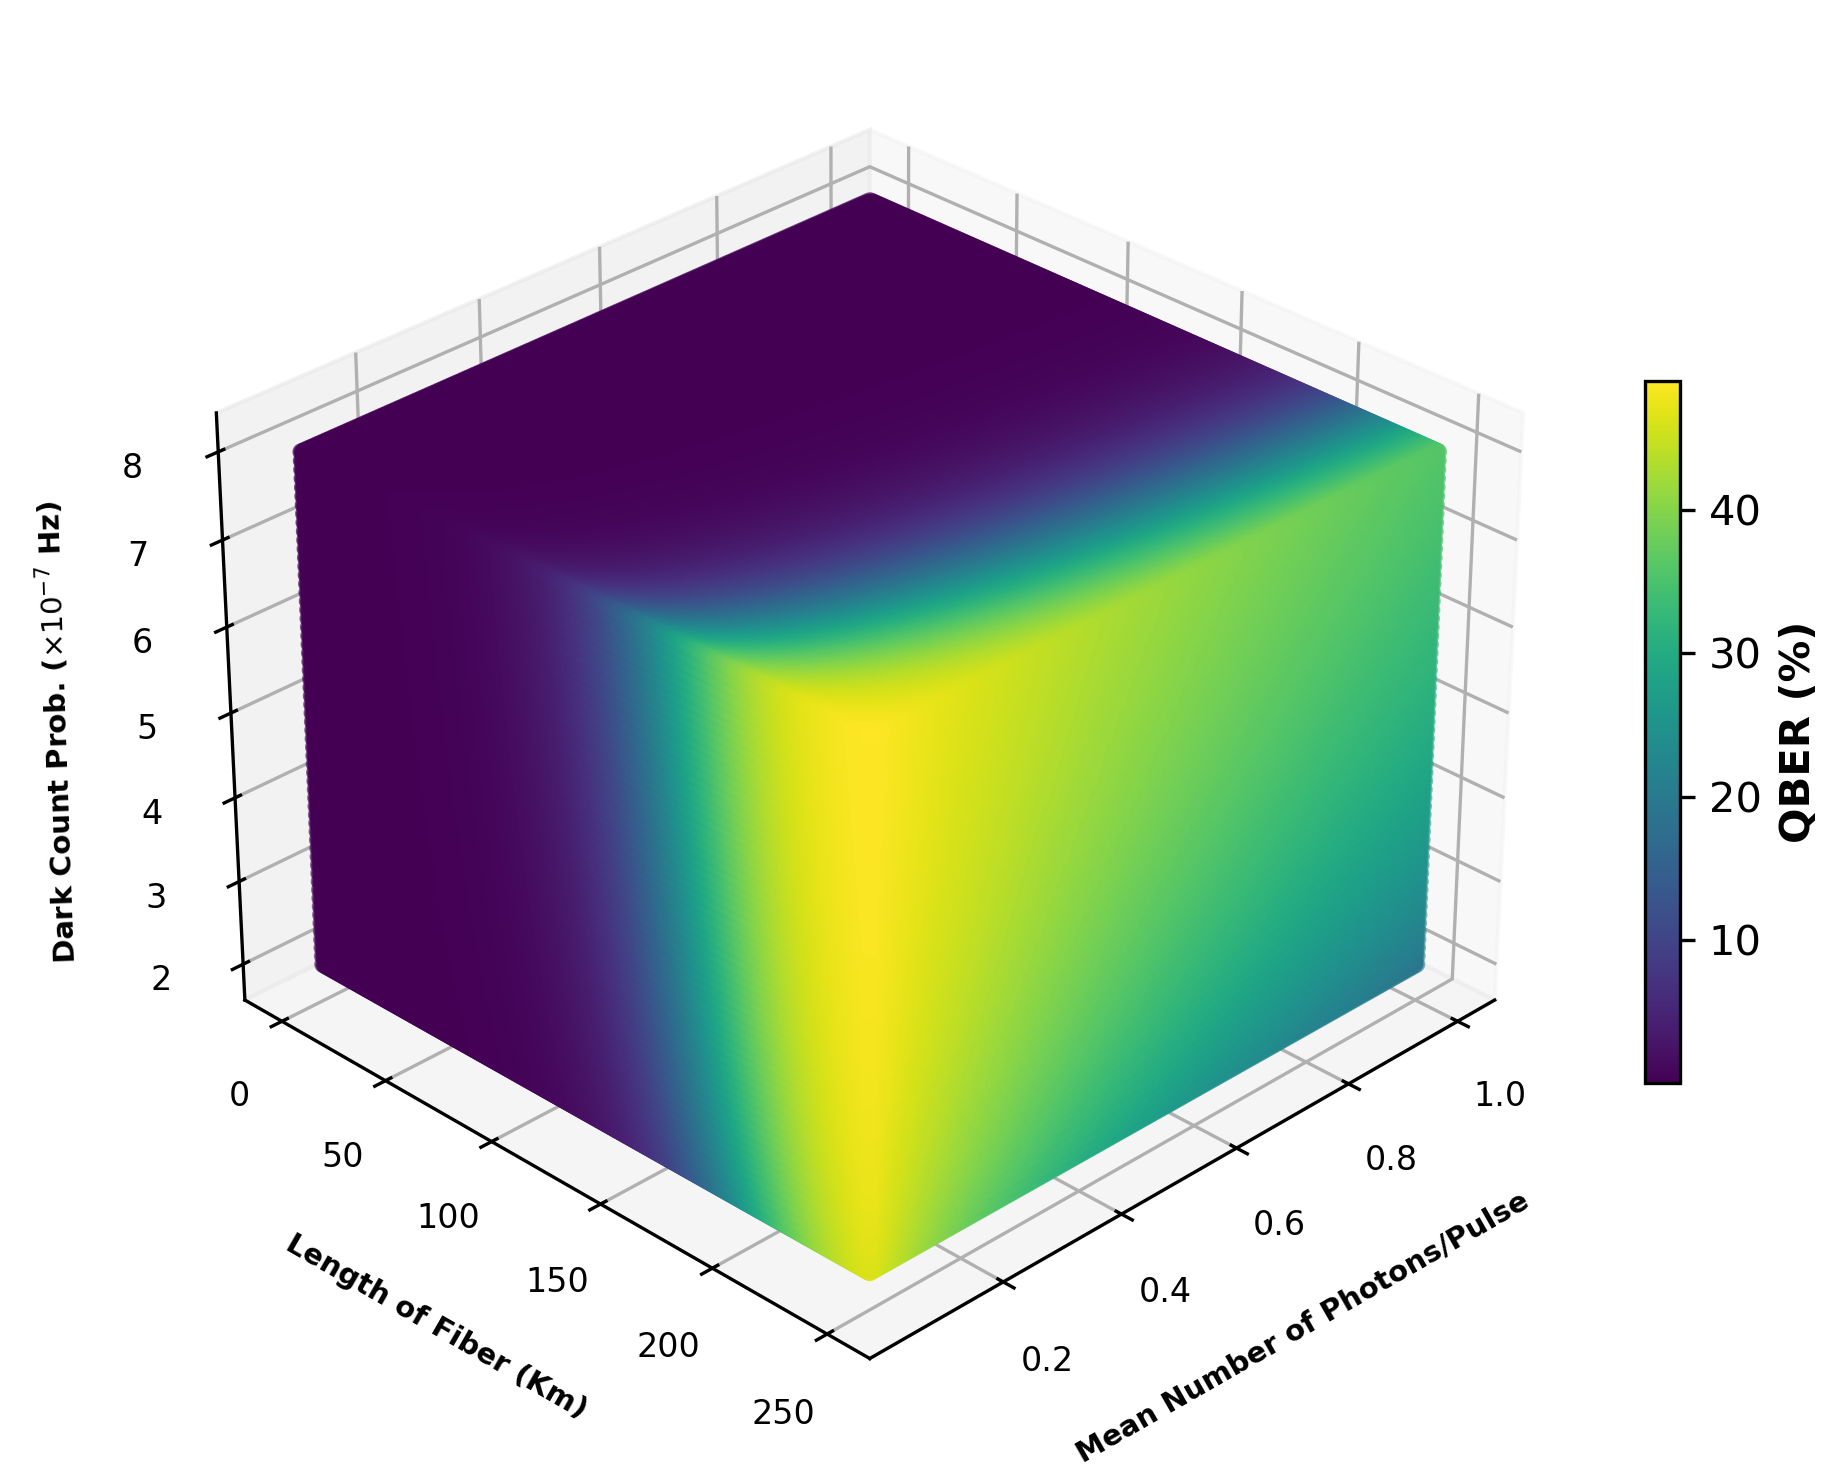

In [2]:

# Plot
fig = plt.figure(figsize=(9, 6.5), dpi=300)
ax = fig.add_axes([0.16, 0.16, 0.68, 0.72], projection='3d')
sc = ax.scatter(Y,X,Z,c=Color,cmap='viridis',s=10)
ax.set_xlabel('Mean Number of Photons/Pulse', fontsize=7, labelpad=8, fontweight='bold')
ax.set_ylabel('Length of Fiber (Km)', fontsize=7, labelpad=8, fontweight='bold')
ax.set_zticks(np.arange(2, 9, 1))
ax.invert_xaxis()
ax.view_init(elev=30, azim=45)
ax.tick_params(axis='both', labelsize=8)
ax.tick_params(axis='z', labelsize=8)
fig.text(0.14,0.52,r'Dark Count Prob. ($\times10^{-7}$ Hz)',rotation=92,fontsize=7,va='center',fontweight='bold')
cbar = fig.colorbar(sc, ax=ax, shrink=0.50, pad=0.05)
cbar.set_label('QBER (%)', fontsize=10, fontweight='bold')
plt.savefig(r"QBER_plot_L_mu_P_d.png",dpi=300, bbox_inches="tight")
plt.show()